In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import argparse
import numpy as np
import random
import scipy
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import kendalltau
import pandas as pd

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
def ERM(G):
    max_number = 0
    for node in G.nodes():   #计算的最大dk2
        neighbors = list(G.neighbors(node))     #节点i的一阶邻居
        di2_max=0
        for node1 in neighbors:
            neighbors1 = list(G.neighbors(node1))     #节点j的一阶邻居
            temp2 = sum(G.degree(neigh) for neigh in neighbors1)
            di2_max = di2_max + temp2
        if di2_max>max_number:
            max_number=di2_max
    # print(max_number)
    length=len(G.nodes())
    my_list_EC=[]
    my_list_SI=[]
    my_list_ERM = []
    for _ in range(length):
        my_list_EC.append(None)
        my_list_SI.append(None)
        my_list_ERM.append(None)
    for node in G.nodes():
        neighbors = list(G.neighbors(node))          #节点i的一阶邻居
        di1 = sum(G.degree(neigh) for neigh in neighbors)
        E1=0
        di2=0
        for node1 in neighbors:
            dj=G.degree(node1)
            temp1=-(dj/di1)*np.log(dj/di1)
            E1=E1+temp1
            neighbors1=list(G.neighbors(node1))
            temp2=sum(G.degree(neigh) for neigh in neighbors1)
            di2=di2+temp2
        # print(di1,di2)
        #print(node)
        # print(E1)
        E2=0
        for node2 in neighbors:
            neighbors2 = list(G.neighbors(node2))  #节点j的一阶邻居
            dj1 = sum(G.degree(neigh) for neigh in neighbors2)
            temp3=-(dj1/di2)*np.log(dj1/di2)
            E2=E2+temp3
        # print(E2)
        lamuda_node=di2/max_number
        # print(lamuda_node)
        EC_node=E1+lamuda_node*E2
        my_list_EC[node]=EC_node
    # print(my_list_EC)
    for node in G.nodes():
        neighbors3=list(G.neighbors(node))
        SI_node=0
        for t in neighbors3:
            SI_node=SI_node+my_list_EC[t]
        my_list_SI[node]=SI_node
    for node in G.nodes():
        neighbors4=list(G.neighbors(node))
        ERM_node=0
        for t in neighbors4:
            ERM_node=ERM_node+my_list_SI[t]
        my_list_ERM[node]=ERM_node
    return  my_list_ERM

In [3]:
def h_index_centrality(graph):
    """
    计算H指数中心性
    :param graph: 无向图，使用字典表示，键为节点，值为与该节点相连的节点列表
    :return: H指数中心性字典，键为节点，值为H指数中心性值
    """
    nodes = []
    for node in graph.nodes():
        nodes.append(node)
    # print(nodes)

    n = len(nodes)
    h_index = {node: 0 for node in nodes}
    for i, node in enumerate(nodes):
        degrees = [len(graph[n]) for n in graph[node]]
        degrees.sort(reverse=True)
        for j, degree in enumerate(degrees):
            if degree >= j + 1:
                h_index[node] = j + 1
            else:
                break
    # h_centrality = {node: h_index[node] / n for node in nodes} 归一化处理
    h_centrality = {node: h_index[node] for node in nodes}

    return h_centrality

In [4]:
def calculate_top_k_jaccard(list1, list2,length):
    """
    计算两个列表按影响力排序后不同Top-K集合的Jaccard相似度
    
    参数:
    list1, list2: 节点影响力列表，下标为节点ID，值为影响力
    k_list: 需要计算的K值列表，默认为[100, 200, 300]
    
    返回:
    字典，键为K，值为对应Jaccard相似度
    """
    # 将列表转换为NumPy数组
    k_list = [int(length*0.05),int(length*0.06),int(length*0.07),int(length*0.08),int(length*0.09),int(length*0.10),int(length*0.11),int(length*0.12),int(length*0.13),int(length*0.14),int(length*0.15),int(length*0.16),int(length*0.17),int(length*0.18),int(length*0.19),int(length*0.20),int(length*0.21),int(length*0.22),int(length*0.23),int(length*0.24),int(length*0.25),int(length*0.26),int(length*0.27),int(length*0.28),int(length*0.29),int(length*0.30),int(length*0.31),int(length*0.32),int(length*0.33),int(length*0.34),int(length*0.35),int(length*0.36),int(length*0.37),int(length*0.38),int(length*0.39),int(length*0.40),int(length*0.41),int(length*0.42),int(length*0.43),int(length*0.44),int(length*0.45),int(length*0.46),int(length*0.47),int(length*0.48),int(length*0.49),int(length*0.50)]
    array1 = np.array(list1)
    array2 = np.array(list2)
    
    # 对数组排序并获取节点ID（argsort默认升序，加负号转为降序）
    sorted_indices1 = np.argsort(-array1)  # array1中影响力从大到小的节点ID
    # print(sorted_indices1)
    sorted_indices2 = np.argsort(-array2)  # array2中影响力从大到小的节点ID
    # print(sorted_indices2)
    # 计算各Top-K的Jaccard相似度
    results = {}
    for k in k_list:
        # 取前k个节点ID形成集合
        top_k_set1 = set(sorted_indices1[:k])
        top_k_set2 = set(sorted_indices2[:k])
        
        # 计算交集和并集大小
        intersection = len(top_k_set1 & top_k_set2)
        union = len(top_k_set1 | top_k_set2)
        
        # 计算Jaccard相似度
        jaccard = intersection / union if union > 0 else 0
        results[k] = jaccard
    
    return results

In [5]:
def kshell(G):
    """
    kshell(G)计算k-shell值
    """
    graph = G.copy()
    importance_dict = {}
    ks = 1
    while graph.nodes():
        temp = []
        node_degrees_dict = gDegree(graph)
        #print(node_degrees_dict)
        kks = min(node_degrees_dict.values())
        if(kks<=ks):
            while True:
                for k, v in node_degrees_dict.items():
                    if v <= ks:
                        temp.append(k)
                        graph.remove_node(k)
                        node_degrees_dict = gDegree(graph)
                if len(graph.nodes()) == 0:
                    break
                else:
                    t=min(node_degrees_dict.values())
                if t>ks :
                    break
                #if kks not in node_degrees_dict.values():
                #   break
            importance_dict[ks] = temp
        ks += 1
    return importance_dict

def gDegree(G):
    """
    将G.degree()的返回值变为字典
    """
    node_degrees_dict = {}
    for i in G.degree():
        node_degrees_dict[i[0]] = i[1]
    return node_degrees_dict.copy()

def LSS(G):
    temp_G=G
    ks=kshell(temp_G)
    num_nodes=len(temp_G.nodes())
    shell_numbers = np.zeros(num_nodes, dtype=float)

    for ks1, nodes in ks.items():
        for node in nodes:
            shell_numbers[node] = ks1
    # print(shell_numbers)
    weight=[]
    for i in range(num_nodes):
        node_degree=temp_G.degree(i)
        weight.append(node_degree*shell_numbers[i])

    # print(weight)


    edg = G.edges()
    adj_matrix = [[0 for _ in range(num_nodes)] for _ in range(num_nodes)]
    adj_matrix = np.array(adj_matrix)
    # print(edg)
    for edg1 in edg:
        adj_matrix[edg1[0]][edg1[1]] = 1
        adj_matrix[edg1[1]][edg1[0]] = 1


    cf_matrix = [[0 for _ in range(num_nodes)] for _ in range(num_nodes)]
    tw_matrix = [[0 for _ in range(num_nodes)] for _ in range(num_nodes)]
    for i in range(num_nodes):
        for j in range(num_nodes):
            if adj_matrix[i][j]==1:
                # 获得相连的两个节点的共同邻居，因为不相连的两个节点不会构成三角形
                neighbors1 = set(G.neighbors(i))
                neighbors2 = set(G.neighbors(j))
                # 找出共同邻居节点
                common_neighbors = neighbors1.intersection(neighbors2)
                #构成的三角形的个数等于共同邻居的节点个数。
                a=len(common_neighbors)
                cf_matrix[i][j]=(shell_numbers[i]-a)*(shell_numbers[j]-a)
                tw_matrix[i][j]=cf_matrix[i][j]*weight[i]*weight[j]/(a+1)
            # else:
            #     cf_matrix[i][j]=(shell_numbers[i]-0)*(shell_numbers[j]-0)
            #     tw_matrix=cf_matrix[i][j]*weight[i]*weight[j]
    # print(cf_matrix[10][1])
    # print(tw_matrix[10][1])
    LSS_matrix=[]
    for i in range(num_nodes):
        sum=0
        nei = G.neighbors(i)
        for j in nei:
            sum = sum + tw_matrix[i][j]
        LSS_matrix.append(shell_numbers[i] * sum / num_nodes)

    return LSS_matrix


In [6]:
def MI(res):
    a=pd.DataFrame(res.detach().numpy())
    x=len(a)
    a.rank(axis=0,method='min',numeric_only=None,
    na_option='keep',ascending=True,pct=False)
    b=a.iloc[:,0].value_counts()
    y=0
    for i in range(len(b)):
        y=y+b.iloc[i]*(b.iloc[i]-1)
    ans=(1-y/(x*(x-1)))*(1-y/(x*(x-1)))
    return ans

In [7]:
edges=np.genfromtxt("DD242.edges",dtype=int)
edges=edges-1
print(edges.shape)
adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
                        shape=(1284, 1284))
adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)
adj_DD242 = torch.FloatTensor(np.array(adj.todense()))
adj=np.array(adj_DD242)
G_DD242 = nx.Graph()
G_DD242 = nx.from_numpy_array(adj)
list_DD242=list(range(1284))

(3303, 2)


In [15]:
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()

In [17]:
start=time.time()
DD242_ERM = ERM(G_DD242)
end=time.time()
print(end-start)
print(MI(torch.tensor(DD242_ERM)))
print("----------------")
for i in range(10, 21):
    t=i/10
    if t!=1.5:
        lable_DD242=np.load("lable/lable_DD242_"+str(t)+".npy")
    else:
        lable_DD242=np.load("lable/lable_DD242.npy")
    lable_DD242_t=torch.tensor(lable_DD242).float()
    tau,_=kendalltau(DD242_ERM,lable_DD242_t)
    print(tau)
print("------------------")
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()
length=len(DD242_ERM)
k_list = [int(length*0.05),int(length*0.1),int(length*0.15),int(length*0.2),int(length*0.25),int(length*0.3),int(length*0.35),int(length*0.4),int(length*0.45),int(length*0.5)]
similarities = calculate_top_k_jaccard(DD242_ERM, lable_DD242_t,length)
for k, sim in similarities.items():
    print(sim)

0.19859051704406738
0.9999538664470123
----------------
0.6927582670833389
0.6316770018726489
0.5890384996651029
0.5377517226938242
0.4961139018598177
0.4513123238763692
0.41547261735524726
0.396709196387656
0.38775780299909757
0.3713019925189106
0.37120791788637036
------------------
0.18518518518518517
0.24193548387096775
0.2624113475177305
0.275
0.26373626373626374
0.26732673267326734
0.2876712328767123
0.29957805907172996
0.31746031746031744
0.3358208955223881
0.34265734265734266
0.33986928104575165
0.3498452012383901
0.3352601156069364
0.35
0.3617021276595745
0.37244897959183676
0.38235294117647056
0.3981042654028436
0.3936651583710407
0.41098901098901097
0.4140127388535032
0.4180327868852459
0.42178217821782177
0.4307692307692308
0.42857142857142855
0.4368231046931408
0.43356643356643354
0.44122657580919933
0.4533333333333333
0.46492659053833607
0.4713375796178344
0.4797507788161994
0.4779969650986343
0.48588410104011887
0.49127906976744184
0.4943181818181818
0.49100968188105115


In [19]:
start=time.time()
DD242_lss = LSS(G_DD242)
end=time.time()
print(end-start)
print(MI(torch.tensor(DD242_lss)))
print("----------------")
for i in range(10, 21):
    t=i/10
    if t!=1.5:
        lable_DD242=np.load("lable/lable_DD242_"+str(t)+".npy")
    else:
        lable_DD242=np.load("lable/lable_DD242.npy")
    lable_DD242_t=torch.tensor(lable_DD242).float()
    tau,_=kendalltau(DD242_lss,lable_DD242_t)
    print(tau)
print("-----------")
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()
length=len(DD242_lss)
k_list = [int(length*0.05),int(length*0.1),int(length*0.15),int(length*0.2),int(length*0.25),int(length*0.3),int(length*0.35),int(length*0.4),int(length*0.45),int(length*0.5)]
similarities = calculate_top_k_jaccard(DD242_lss, lable_DD242_t,length)
for k, sim in similarities.items():
    # print(f"Top-{k} Jaccard Similarity: {sim:.4f}")
    print(sim)

1.500849723815918
0.9987038096981503
----------------
0.39642655262648335
0.4031069403130109
0.4114393953127209
0.40161983756737774
0.39956004105116133
0.3876823057469026
0.3626049858430699
0.3580597451554789
0.3461865814515151
0.34749402020223014
0.3421874955333397
-----------
0.0847457627118644
0.1
0.11949685534591195
0.14606741573033707
0.15
0.1743119266055046
0.1799163179916318
0.17557251908396945
0.19855595667870035
0.21768707482993196
0.23076923076923078
0.2693498452012384
0.28994082840236685
0.2905027932960894
0.2925531914893617
0.29620253164556964
0.31862745098039214
0.3333333333333333
0.3563218390804598
0.37193763919821826
0.38362068965517243
0.39622641509433965
0.39235412474849096
0.3861003861003861
0.3828996282527881
0.397459165154265
0.4038800705467372
0.4017094017094017
0.41
0.4201954397394137
0.4231378763866878
0.4370139968895801
0.4393939393939394
0.45156482861400893
0.45985401459854014
0.46153846153846156
0.4692737430167598
0.4787379972565158
0.48787061994609165
0.49403

In [415]:
start=time.time()
eigenvector_centrality = nx.eigenvector_centrality(G_DD242,max_iter=1000,tol=3e-3)
# eigenvector_centrality = nx.eigenvector_centrality_numpy(G_DD242)
# print(centrality)
DD242_ec=[0 for _ in range(nums_nodes)]
print(nums_nodes) 
for i,j in eigenvector_centrality.items():
    DD242_ec[i]=j
end=time.time()
print(end-start)
print(MI(torch.tensor(DD242_ec)))
print("--------------------")
for i in range(10, 21):
    t=i/10
    if t!=1.5:
        lable_DD242=np.load("lable/lable_DD242_"+str(t)+".npy")
    else:
        lable_DD242=np.load("lable/lable_DD242.npy")
    lable_DD242_t=torch.tensor(lable_DD242).float()
    tau,_=kendalltau(DD242_ec,lable_DD242_t)
    print(tau)
print("------------------")
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()
similarities = calculate_top_k_jaccard(DD242_ec, lable_DD242_t,length)
for k, sim in similarities.items():
    print(sim)

1284
0.006999492645263672
0.9570352262550598
--------------------
0.6437565597095362
0.5799954287480892
0.5325673271710188
0.48326467433595555
0.4436372667218231
0.4033365594707912
0.3713717389274963
0.3539978325291928
0.35122041555132955
0.33285161193730495
0.3345263928861647
------------------
0.20754716981132076
0.232
0.22758620689655173
0.25925925925925924
0.26373626373626374
0.26732673267326734
0.27601809954751133
0.2833333333333333
0.31746031746031744
0.32592592592592595
0.31958762886597936
0.3225806451612903
0.3252279635258359
0.3125
0.32065217391304346
0.32987012987012987
0.341645885286783
0.34285714285714286
0.3532110091743119
0.3568281938325991
0.3630573248407643
0.3817427385892116
0.3867735470941884
0.39147286821705424
0.39587242026266417
0.4
0.413854351687389
0.42114384748700173
0.4218487394957983
0.42716857610474634
0.4391025641025641
0.4392523364485981
0.44376899696048633
0.44510385756676557
0.447178002894356
0.4491525423728814
0.4590846047156727
0.46070460704607047
0.466

In [417]:
start=time.time()
degrees = G_DD242.degree()
DD242_degree=[0 for _ in range(nums_nodes)]
for node,degree in degrees:
    DD242_degree[node]=degree
end=time.time()
print(end-start)
print(MI(torch.tensor(DD242_degree)))
print("-----------------------")
for i in range(10, 21):
    t=i/10
    if t!=1.5:
        lable_DD242=np.load("lable/lable_DD242_"+str(t)+".npy")
    else:
        lable_DD242=np.load("lable/lable_DD242.npy")
    lable_DD242_t=torch.tensor(lable_DD242).float()
    tau,_=kendalltau(DD242_degree,lable_DD242_t)
    print(tau)
print("------------------")
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()
similarities = calculate_top_k_jaccard(DD242_degree, lable_DD242_t,length)
for k, sim in similarities.items():
    print(sim)

0.001001119613647461
0.6601229587588245
-----------------------
0.5966530359885591
0.5386924522492174
0.4904830782731877
0.44390804700698533
0.4047587008542873
0.3723772699379465
0.34012388384043296
0.3258815003463244
0.325759925832482
0.30933556704762205
0.31180701322968146
------------------
0.12280701754385964
0.15789473684210525
0.17105263157894737
0.21428571428571427
0.20418848167539266
0.21904761904761905
0.20512820512820512
0.20784313725490197
0.23880597014925373
0.26501766784452296
0.271523178807947
0.29337539432176657
0.30930930930930933
0.30140845070422534
0.30997304582210244
0.30612244897959184
0.3154034229828851
0.3146853146853147
0.319910514541387
0.3247311827956989
0.3182751540041068
0.332
0.33076923076923076
0.3370577281191806
0.3381294964028777
0.34851138353765326
0.35604770017035775
0.3712374581939799
0.37337662337662336
0.3885350318471338
0.39009287925696595
0.3978819969742814
0.39500734214390604
0.4014388489208633
0.40646976090014064
0.41127922971114167
0.42162162162

In [419]:
start=time.time()
h_index=h_index_centrality(G_DD242)
DD242_hindex=[0 for _ in range(nums_nodes)]
for node,hindex in h_index.items():
    DD242_hindex[node]=hindex
end=time.time()
print(end-start)
print(MI(torch.tensor(DD242_hindex)))
print("---------------")
for i in range(10, 21):
    t=i/10
    if t!=1.5:
        lable_DD242=np.load("lable/lable_DD242_"+str(t)+".npy")
    else:
        lable_DD242=np.load("lable/lable_DD242.npy")
    lable_DD242_t=torch.tensor(lable_DD242).float()
    tau,_=kendalltau(DD242_hindex,lable_DD242_t)
    print(tau)
print("------------------")
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()
similarities = calculate_top_k_jaccard(DD242_hindex, lable_DD242_t,length)
for k, sim in similarities.items():
    print(sim)

0.0060002803802490234
0.4908975000215048
---------------
0.6030087343623558
0.5514227898056796
0.5063262538760361
0.4585280328532914
0.4248626869050402
0.38782157821513036
0.3559619279831508
0.3422237394705597
0.3279886194006825
0.31765162570129524
0.31579496547698227
------------------
0.10344827586206896
0.15789473684210525
0.17105263157894737
0.19298245614035087
0.19170984455958548
0.19626168224299065
0.20512820512820512
0.1891891891891892
0.2116788321167883
0.21768707482993196
0.21518987341772153
0.22388059701492538
0.24571428571428572
0.2554347826086957
0.25257731958762886
0.24878048780487805
0.26588235294117646
0.26741573033707866
0.29385964912280704
0.28870292887029286
0.3048780487804878
0.3240556660039761
0.32821497120921306
0.33955223880597013
0.3551912568306011
0.36283185840707965
0.37005163511187605
0.37353433835845895
0.3891625615763547
0.3996789727126806
0.4097331240188383
0.4171779141104294
0.4200298953662182
0.4281524926686217
0.43061516452074394
0.4309623430962343
0.433

In [26]:
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()
node_feature_DD242=torch.load("EC做损失的特征向量/node_feature_DD242_LSTM_EC_0.005_500.pt")
node_feature_DD242 = min_max_normalization(node_feature_DD242)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

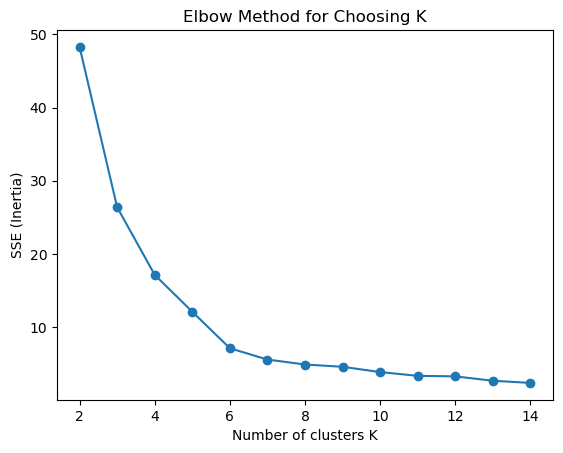

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 假设你的特征矩阵叫 node_feature_vidal
X = node_feature_DD242.detach().numpy()

# 1. 肘部法则（Elbow Method）
sse = []
k_list = range(2, 15)  # 尝试K从2到14
for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_就是SSE

plt.figure()
plt.plot(k_list, sse, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Choosing K')
plt.show()

In [29]:
def min_max_normalization(tensor):
    # 找出数组的最小值和最大值
    min_val = torch.min(tensor)
    max_val = torch.max(tensor)

    # 进行最小 - 最大标准化
    normalized_tensor = (tensor - min_val) / (max_val - min_val)
    return normalized_tensor
# node_feature_BA = min_max_normalization(node_feature_BA)
# node_feature_BA1 = min_max_normalization(node_feature_BA1)

In [80]:
class GNN(torch.nn.Module):
    def __init__(self,input_feature,output_feature):
        super(GNN,self).__init__()
        self.w = nn.Parameter(torch.empty(size=(input_feature,output_feature)))
        self.a= nn.Parameter(torch.empty(size=(1,output_feature)))
        self.sigmod=torch.nn.Sigmoid()
        self.reset_parameters()
    def reset_parameters(self):
        #nn.init.xavier_uniform_(self.w.data,gain=1.414)
        #nn.init.xavier_uniform_(self.a.data,gain=1.414)
        for param in self.parameters():
             nn.init.xavier_uniform_(param)
        
    def forward(self,x,adj):
        adj=torch.Tensor(adj.numpy()+np.identity(adj.shape[0]))
        # adj=torch.FloatTensor(normalize_adj(sp.csr_matrix(adj)+ sp.eye(adj.shape[0])).todense())
        x=torch.mm(adj,x)
        x=torch.mm(x,self.w)
        x=x.add(self.a)
        x=torch.relu(x)
        return x


class CGNN(torch.nn.Module):
    def __init__(self):
        super(CGNN,self).__init__()
        self.layer2=GNN(48,6)
        self.layer3=GNN(6,12)
        # self.fc1=torch.nn.Linear(6,12)
        self.fc1=torch.nn.Linear(12,1)
        # self.fc2=torch.nn.Linear(24,1)
        
        
       
     
    
    
    def forward(self,x,adj,target_nodes):
        #x=self.layer1(x)
        # x=torch.cat([x1,x],dim=-1)
        # x=0.5*x+0.5*x1
        x=self.layer2(x,adj)
        x=self.layer3(x,adj)
       # x=self.layer4(x,adj)
        
        x=x[target_nodes]
        
        x=self.fc1(x.view(x.size(0),-1))
        x=torch.relu(x)
        # x=self.fc2(x)
        # x=torch.relu(x)
        x=x.flatten()
        
        return x

In [82]:
import optuna
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau

# 假设你的模型和数据已定义
# from your_model import CGNN  # 导入你的CGNN模型
# 假设以下变量已提前定义：
# node_feature_DD242, adj_DD242, train_idx, list_DD242, list_pinggu
# train_DD242_lable, pinggu_true  # 训练标签和验证集真实值

def objective(trial):
    # 1. 定义超参数搜索空间
    learning_rate = trial.suggest_float(
        "learning_rate", 
        low=0.001, 
        high=0.01,
        step=0.001  # 学习率：0.001-0.01，步长0.001
    )
    epochs = trial.suggest_int(
        "epochs", 
        low=100, 
        high=3000, # 训练次数：100-1000之间的任意整数
        step=100
    )

    epoch_1=trial.suggest_int(
        "epoch_1", 
        low=100, 
        high=500, # 训练次数：100-1000之间的任意整数
        step=100
    )
    learning_rate1 = trial.suggest_categorical(
        "learning_rate1", 
        [0.005,0.001,0.01] # 仅允许这三个候选值
    )
    # 2. 初始化模型和优化器

    lable_DD242=np.load("lable/lable_DD242.npy")
    lable_DD242_t=torch.tensor(lable_DD242).float()
    node_feature_DD242=torch.load("EC做损失的特征向量/node_feature_DD242_LSTM_EC_"+str(learning_rate1)+"_"+str(epoch_1)+".pt")
    node_feature_DD242 = min_max_normalization(node_feature_DD242)
    
    random.seed(17)
    np.random.seed(17)
    torch.manual_seed(17)
    
# 设置聚类数量
    k = 6
    X = node_feature_DD242.detach().numpy()

# 执行 KMeans 聚类
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
    cluster_nodes = {i: [] for i in range(k)}
    for idx, label in enumerate(labels):
        cluster_nodes[label].append(idx)
#选择训练集的节点
    n_nodes = node_feature_DD242.shape[0]

# 1. 随机采样 5% 的节点索引
    # 1. 随机采样 5% 的节点索引
    num_train = int(0.05 * n_nodes)+1

    train_idx=[]
    while len(train_idx) < num_train:
        for i in range(k):
            if cluster_nodes[i]:  # 确保当前簇中还有节点可取
                node = random.choice(cluster_nodes[i])  # 随机选一个
                train_idx.append(node)
                cluster_nodes[i].remove(node)
                if len(train_idx) >= num_train:
                    break

    pinggu_idx=[]
    while len(pinggu_idx) < num_train:
        for i in range(k):
            if cluster_nodes[i]:  # 确保当前簇中还有节点可取
                node = random.choice(cluster_nodes[i])  # 随机选一个
                pinggu_idx.append(node)
                cluster_nodes[i].remove(node)
                if len(pinggu_idx) >= num_train:
                    break

# 2. 构造训练集（只选取部分节点特征）
    train_DD242 = node_feature_DD242[train_idx]
    train_DD242_lable = lable_DD242_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
    pinggu_DD242 = node_feature_DD242[pinggu_idx]
    pinggu_DD242_lable = lable_DD242_t[pinggu_idx]


    
    # 2. 初始化模型和优化器
    random.seed(17)
    np.random.seed(17)
    torch.manual_seed(17)
    model = CGNN()  # 实例化你的模型
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4  # 保持权重衰减不变
    )
    
    # 3. 训练模型
    for epoch in range(epochs):
        # 训练过程（复用你的train函数逻辑）
        model.train()
        output = model(node_feature_DD242.data, adj_DD242, train_idx)
        loss_train = torch.nn.functional.mse_loss(output, train_DD242_lable)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # 每100轮打印一次中间结果（可选）
        if (epoch + 1) % 100 == 0:
            print(f"当前参数组合: 学习率={learning_rate}, 训练次数={epochs}, 轮次={epoch+1}, 训练损失={loss_train.item():.4f}")
    
    # 4. 在验证集上评估RMSE
    model.eval()
    with torch.no_grad():  # 关闭梯度计算，节省内存
        pinggu_pre = model(node_feature_DD242.data, adj_DD242, pinggu_idx)
        # 转换为numpy数组计算RMSE
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true=pinggu_DD242_lable.detach().numpy()
        # print(kendalltau(pinggu_pre_np,pinggu_pre_np))
        rmse=kendalltau(pinggu_pre_np,pinggu_true).statistic
        # rmse = np.sqrt(np.mean((pinggu_true - pinggu_pre_np) **2))
    
    # 5. 返回需要最小化的RMSE（Optuna会寻找最小RMSE对应的参数）
    return rmse

if __name__ == '__main__':
    # 创建优化实例，方向为"最小化"RMSE
    study = optuna.create_study(direction="maximize")
    # 尝试20组参数组合
    study.optimize(objective, n_trials=50)
    
    # 输出最优结果
    print("\n优化完成！")
    print(f"最佳参数组合: {study.best_params}")
    print(f"最小RMSE: {study.best_value:.4f}")
    print(f"最佳试验编号: {study.best_trial.number}")

[I 2026-07-26 21:14:12,970] A new study created in memory with name: no-name-151c795a-3f3d-4e82-b029-dfe64a0508d8
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
[W 2026-07-26 21:14:14,025] Trial 0 failed with parameters: {'learning_rate': 0.006, 'epochs': 2900, 'epoch_1': 300, 'learning_rate1': 0.005} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Administrator\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Local\Temp\ipykernel_23004\986768400.py", line 116, in objective
    output = model(node_feature_DD242.data, adj_DD242, train_idx)
           

KeyboardInterrupt: 

In [98]:
node_feature_DD242=torch.load("EC做损失的特征向量/node_feature_DD242_layer3_LSTM_EC_0.005_200.pt")
node_feature_DD242 = min_max_normalization(node_feature_DD242)
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()

In [100]:
import numpy as np
from sklearn.cluster import KMeans
# 假设 node_feature_DD242 是你的节点特征矩阵，形状是 (num_nodes, feature_dim)
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
    
# 设置聚类数量
k = 5
X = node_feature_DD242.detach().numpy()

# 执行 KMeans 聚类
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
cluster_nodes = {i: [] for i in range(k)}
for idx, label in enumerate(labels):
    cluster_nodes[label].append(idx)
#选择训练集的节点
n_nodes = node_feature_DD242.shape[0]

# 1. 随机采样 5% 的节点索引
num_train = int(0.05 * n_nodes)+1

train_idx=[]
while len(train_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            train_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(train_idx) >= num_train:
                break

pinggu_idx=[]
while len(pinggu_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            pinggu_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(pinggu_idx) >= num_train:
                break

# 2. 构造训练集（只选取部分节点特征）
train_DD242 = node_feature_DD242[train_idx]
train_DD242_lable = lable_DD242_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
pinggu_DD242 = node_feature_DD242[pinggu_idx]
pinggu_DD242_lable = lable_DD242_t[pinggu_idx]

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [102]:
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau

# 确保随机种子完全一致
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
# 对于CUDA环境，还需固定cuda随机种子
if torch.cuda.is_available():
    torch.cuda.manual_seed(17)
    torch.cuda.manual_seed_all(17)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train(epoch, model, optimizer, node_feature, adj, train_idx, train_label):
    model.train()
    output = model(node_feature.data, adj, train_idx)
    loss = torch.nn.functional.mse_loss(output, train_label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

if __name__ == '__main__':
    # 确保数据与Optuna调优时完全一致
    # （需与objective函数中使用的node_feature_DD242、adj_DD242等保持相同）
    # 假设以下变量已正确定义：
    # node_feature_DD242, adj_DD242, train_idx, train_DD242_lable, sum_idx, sum_DD242_lable
    
    # 初始化模型和优化器（与Optuna中完全一致）
    model = CGNN()  # 重新初始化，确保权重初始状态一致
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.008885296891964298,  # Optuna找到的最佳学习率
        weight_decay=5e-4
    )
    
    # 记录总训练时间
    t_total = time.time()
    loss_values = []
    
    # 训练600轮（与Optuna最佳参数一致）
    for epoch in range(1000):
        loss = train(epoch, model, optimizer, node_feature_DD242, adj_DD242, train_idx, train_DD242_lable)
        loss_values.append(loss)
        
        # 每100轮打印训练损失（与Optuna中保持一致的监控频率）
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, 训练损失: {loss:.4f}")
    
    # 关键：添加与Optuna中完全一致的评估步骤
    model.eval()
    with torch.no_grad():
        # 使用相同的评估索引和标签
        pinggu_pre = model(node_feature_DD242.data, adj_DD242, pinggu_idx)
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true = pinggu_DD242_lable.detach().numpy()
        # 计算Kendall系数（与Optuna中评估指标一致）
        kendall = kendalltau(pinggu_pre_np, pinggu_true).statistic
        print(f"最终Kendall系数: {kendall:.6f}")
    
    print("Optimization Finished!")
    print(f"Total time elapsed: {time.time() - t_total:.2f}s")

Epoch 100, 训练损失: 58.5768
Epoch 200, 训练损失: 45.1747
Epoch 300, 训练损失: 41.1352
Epoch 400, 训练损失: 39.5821
Epoch 500, 训练损失: 38.2999
Epoch 600, 训练损失: 36.3872
Epoch 700, 训练损失: 35.7469
Epoch 800, 训练损失: 34.1721
Epoch 900, 训练损失: 33.4401
Epoch 1000, 训练损失: 32.8199
最终Kendall系数: 0.629478
Optimization Finished!
Total time elapsed: 31.04s


In [103]:
lable_DD242=np.load("lable/lable_DD242.npy")
lable_DD242_t=torch.tensor(lable_DD242).float()

In [104]:
model_cgnn=model
model_cgnn.eval()
start=time.time()
output = model_cgnn(node_feature_DD242.data,adj_DD242,list_DD242)


# for i in train_idx:
#     output[i]=lable_DD242_t[i]
# for i in pinggu_idx:
#     output[i]=lable_DD242_t[i]
    
# end=time.time()
# print(end-start)
# output_rank=output.detach().numpy().argsort()

# print(output_rank)
# print(label_rank)
loss_train = torch.nn.functional.mse_loss(output,lable_DD242_t)
# print(loss_train)
print(kendalltau(output.detach().numpy(),lable_DD242_t))
print(MI(output))

SignificanceResult(statistic=0.45822620579228157, pvalue=1.5333492361924601e-133)
0.9999538664470123


In [443]:
length=len(output)
k_list = [int(length*0.05),int(length*0.1),int(length*0.15),int(length*0.2),int(length*0.25),int(length*0.3),int(length*0.35),int(length*0.4),int(length*0.45),int(length*0.5)]
similarities = calculate_top_k_jaccard(output.detach().numpy(), lable_DD242_t,length)
for k, sim in similarities.items():
    print(sim)

0.20754716981132076
0.2222222222222222
0.2108843537414966
0.25153374233128833
0.26373626373626374
0.26108374384236455
0.2702702702702703
0.27800829875518673
0.30196078431372547
0.3161764705882353
0.33797909407665505
0.3442622950819672
0.3498452012383901
0.3391304347826087
0.35376044568245124
0.36533333333333334
0.37948717948717947
0.3891625615763547
0.40476190476190477
0.4031890660592255
0.42350332594235035
0.4291845493562232
0.432712215320911
0.43887775551102204
0.453125
0.4500941619585687
0.45787545787545786
0.4669051878354204
0.47130434782608693
0.48047538200339557
0.48184818481848185
0.49032258064516127
0.4890282131661442
0.49157733537519144
0.5015015015015015
0.5066079295154186
0.5136690647482014
0.5076923076923077
0.5227586206896552
0.5346938775510204
0.5366178428761651
0.5505913272010512
0.5541237113402062
0.5555555555555556
0.5685785536159601
0.5773955773955773


In [ ]:
# Trial 98 finished with value: 0.9096213445932212 and parameters: {'learning_rate': 0.016, 'epochs': 2800, 'epoch_1': 400, 'learning_rate1': 0.01}.5jucu

# {'learning_rate': 0.01, 'epochs': 2000, 'epoch_1': 500, 'learning_rate1': 0.001} 6个聚簇     0.4665316066185619

 #  {'learning_rate': 0.007, 'epochs': 600, 'epoch_1': 200, 'learning_rate1': 0.005}. 5个聚簇   0.4745674461899543  我觉得次优
# {'learning_rate': 0.009000000000000001, 'epochs': 1300, 'epoch_1': 500, 'learning_rate1': 0.001}.  6个聚簇  0.4964908487382388   这个目前较优解

#{'learning_rate': 0.008885296891964298, 'epochs': 1000, 'epoch_1': 200, 'learning_rate1': 0.005}  0.4736810510725296 最优

## Random representative-node sensitivity (seeds 12-22)

Sampling ratio is fixed at 5%, K is fixed at 5 (matching the original DD242 baseline), the K-means seed is fixed at 42, and the model-initialization seed is fixed at 17. Only the random seed used to select nodes within each cluster changes. No validation set is used. Kendall's tau is calculated from raw predictions over the whole DD242 network.

In [108]:
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from scipy.stats import kendalltau
from sklearn.cluster import KMeans

# Fixed experiment settings. Only the representative-node selection seed changes.
SAMPLE_RATIO = 0.2
N_CLUSTERS = 5
KMEANS_SEED = 42
MODEL_SEED = 17
LEARNING_RATE = 0.008885296891964298
WEIGHT_DECAY = 5e-4
EPOCHS = 1000
SELECTION_SEEDS = range(12, 23)

# Load the same labels and node features for every seed.
lable_DD242 = np.load("lable/lable_DD242.npy")
lable_DD242_t = torch.tensor(lable_DD242).float()
node_feature_DD242 = torch.load("EC做损失的特征向量/node_feature_DD242_LSTM_EC_0.005_200.pt")
node_feature_DD242 = min_max_normalization(node_feature_DD242)

# Match the original experiment: keep sklearn's default n_init.
X = node_feature_DD242.detach().cpu().numpy()
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=KMEANS_SEED)
cluster_labels = kmeans.fit_predict(X)
n_nodes = node_feature_DD242.shape[0]
num_train = int(np.ceil(SAMPLE_RATIO * n_nodes))
all_nodes = list(range(n_nodes))

seed_results = []

for selection_seed in SELECTION_SEEDS:
    cluster_nodes = {
        cluster_id: np.where(cluster_labels == cluster_id)[0].tolist()
        for cluster_id in range(N_CLUSTERS)
    }

    selection_rng = random.Random(selection_seed)
    train_idx = []
    while len(train_idx) < num_train:
        for cluster_id in range(N_CLUSTERS):
            if cluster_nodes[cluster_id]:
                node = selection_rng.choice(cluster_nodes[cluster_id])
                train_idx.append(node)
                cluster_nodes[cluster_id].remove(node)
                if len(train_idx) >= num_train:
                    break

    train_labels = lable_DD242_t[train_idx]

    # Keep model initialization identical across all selection seeds.
    random.seed(MODEL_SEED)
    np.random.seed(MODEL_SEED)
    torch.manual_seed(MODEL_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(MODEL_SEED)
        torch.cuda.manual_seed_all(MODEL_SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    model_seed_run = CGNN()
    optimizer_seed_run = optim.Adam(
        model_seed_run.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    train_start = time.perf_counter()
    for epoch in range(EPOCHS):
        model_seed_run.train()
        train_output = model_seed_run(
            node_feature_DD242.data,
            adj_DD242,
            train_idx,
        )
        train_loss = torch.nn.functional.mse_loss(train_output, train_labels)
        optimizer_seed_run.zero_grad()
        train_loss.backward()
        optimizer_seed_run.step()
    training_seconds = time.perf_counter() - train_start

    # Whole-network evaluation using raw predictions; no validation set is used.
    model_seed_run.eval()
    with torch.no_grad():
        full_output = model_seed_run(
            node_feature_DD242.data,
            adj_DD242,
            all_nodes,
        ).detach()
        kendall_full = kendalltau(
            full_output.cpu().numpy(),
            lable_DD242_t.cpu().numpy(),
        ).statistic

    seed_results.append({
        "selection_seed": selection_seed,
        "sample_ratio": SAMPLE_RATIO,
        "n_clusters": N_CLUSTERS,
        "n_selected": len(train_idx),
        "kendall_full_network": kendall_full,
        "training_seconds": training_seconds,
    })
    print(
        f"seed={selection_seed:2d} | selected={len(train_idx):3d} | "
        f"Kendall(full network)={kendall_full:.6f} | "
        f"training={training_seconds:.2f}s"
    )

seed_results_df = pd.DataFrame(seed_results)
seed_results_df.to_csv(
    "DD242_0.2_random_seed_12_22_kendall.csv",
    index=False,
    encoding="utf-8-sig",
)

kendall_mean = seed_results_df["kendall_full_network"].mean()
kendall_std = seed_results_df["kendall_full_network"].std(ddof=1)
kendall_min = seed_results_df["kendall_full_network"].min()
kendall_max = seed_results_df["kendall_full_network"].max()

display(seed_results_df)
print(f"Kendall mean +/- std: {kendall_mean:.6f} +/- {kendall_std:.6f}")
print(f"Kendall range: [{kendall_min:.6f}, {kendall_max:.6f}]")
print("Saved to DD242_random_seed_12_22_kendall.csv")

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


seed=12 | selected=257 | Kendall(full network)=0.495103 | training=49.26s
seed=13 | selected=257 | Kendall(full network)=0.491683 | training=46.06s
seed=14 | selected=257 | Kendall(full network)=0.452830 | training=51.14s
seed=15 | selected=257 | Kendall(full network)=0.500977 | training=45.03s
seed=16 | selected=257 | Kendall(full network)=0.481231 | training=50.60s
seed=17 | selected=257 | Kendall(full network)=0.449272 | training=52.32s
seed=18 | selected=257 | Kendall(full network)=0.467286 | training=44.99s
seed=19 | selected=257 | Kendall(full network)=0.461852 | training=50.36s
seed=20 | selected=257 | Kendall(full network)=0.495185 | training=45.98s
seed=21 | selected=257 | Kendall(full network)=0.490969 | training=46.45s
seed=22 | selected=257 | Kendall(full network)=0.471738 | training=49.47s


,selection_seed,sample_ratio,n_clusters,n_selected,kendall_full_network,training_seconds
0,12,0.2,5,257,0.495103,49.257360
1,13,0.2,5,257,0.491683,46.058193
2,14,0.2,5,257,0.452830,51.135732
3,15,0.2,5,257,0.500977,45.026662
4,16,0.2,5,257,0.481231,50.603611
5,17,0.2,5,257,0.449272,52.322057
6,18,0.2,5,257,0.467286,44.987100
7,19,0.2,5,257,0.461852,50.361042
8,20,0.2,5,257,0.495185,45.978537
9,21,0.2,5,257,0.490969,46.450476


Kendall mean +/- std: 0.478012 +/- 0.018317
Kendall range: [0.449272, 0.500977]
Saved to DD242_random_seed_12_22_kendall.csv
